In [12]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn




In [13]:
from pathlib import Path

sns.set_theme(style="whitegrid")

results_path = Path("results/baseline_test_results.json")
with results_path.open("r") as f:
    baseline = json.load(f)

overall_rows = []
class_rows = []

for model_name, train_dict in baseline.items():
    for train_split, test_dict in train_dict.items():
        for test_split, metrics in test_dict.items():
            overall_rows.append(
                {
                    "model": model_name,
                    "train_split": train_split,
                    "test_split": test_split,
                    "overall_acc": metrics["overall"],
                }
            )
            for class_name, class_metrics in metrics["per_class"].items():
                class_rows.append(
                    {
                        "model": model_name,
                        "train_split": train_split,
                        "test_split": test_split,
                        "class": class_name,
                        "acc": class_metrics["acc"],
                        "correct": class_metrics["correct"],
                        "total": class_metrics["total"],
                    }
                )

df_overall = pd.DataFrame(overall_rows)
df_class = pd.DataFrame(class_rows)

model_name_map = {
    "bam": "CBAM",
    "res": "Resnet",
    "vis": "Swin T",
}

df_overall["model"] = df_overall["model"].replace(model_name_map)
df_class["model"] = df_class["model"].replace(model_name_map)

print(f"Loaded {len(df_overall)} overall rows and {len(df_class)} class rows")
df_overall.head()

Loaded 48 overall rows and 240 class rows


,model,train_split,test_split,overall_acc
0,CBAM,os1,os1,77.6992
1,CBAM,os1,os2,63.1143
2,CBAM,os1,fusar,38.2958
3,CBAM,os1,all,63.9887
4,CBAM,os2,os1,77.1806


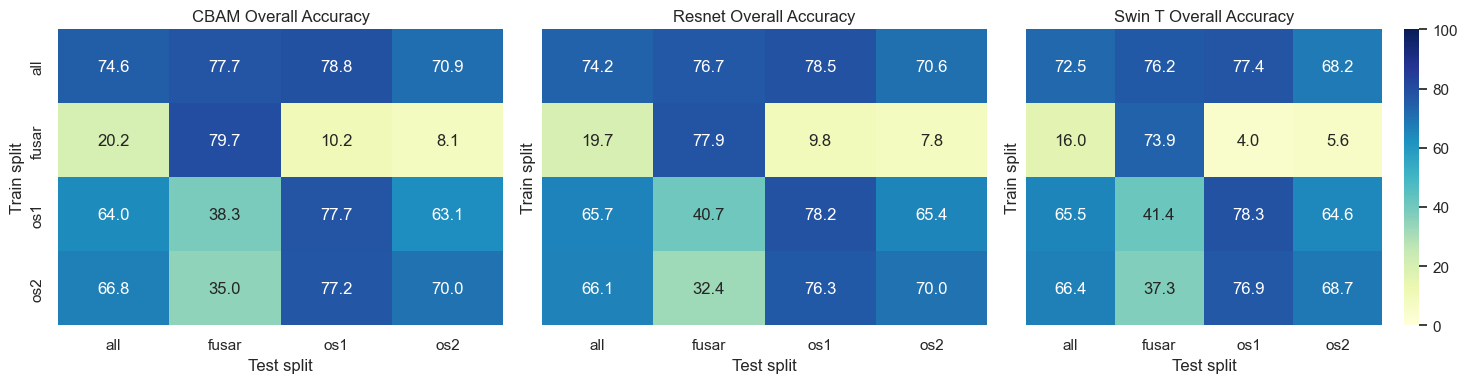

In [14]:
models = sorted(df_overall["model"].unique())
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4), sharey=True)

if len(models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, models):
    pivot = (
        df_overall[df_overall["model"] == model_name]
        .pivot(index="train_split", columns="test_split", values="overall_acc")
        .sort_index()
    )
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        cbar=ax is axes[-1],
        ax=ax,
        vmin=0,
        vmax=100,
    )
    ax.set_title(f"{model_name} Overall Accuracy")
    ax.set_xlabel("Test split")
    ax.set_ylabel("Train split")

plt.tight_layout()
plt.show()

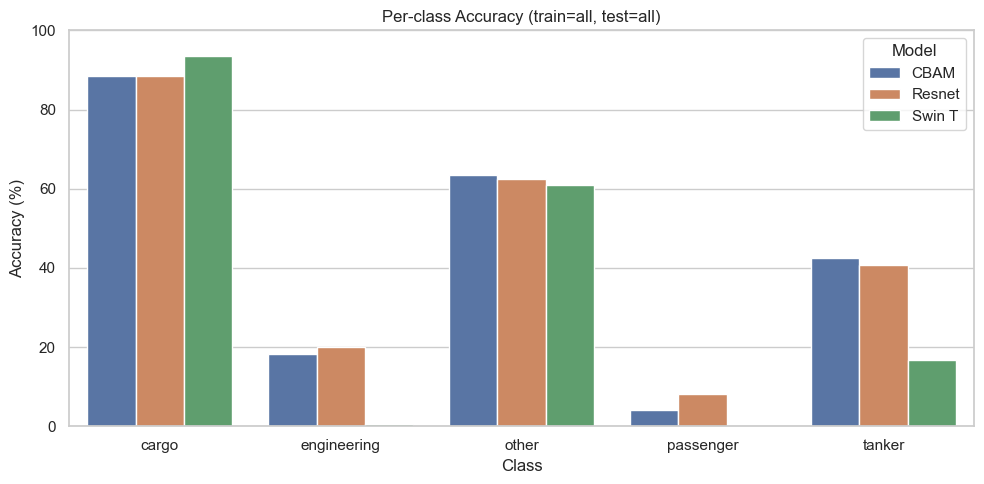

,model,train_split,test_split,class,acc,correct,total
235,Swin T,all,all,cargo,93.6471,3980,4250
75,CBAM,all,all,cargo,88.5647,3764,4250
155,Resnet,all,all,cargo,88.4706,3760,4250
156,Resnet,all,all,engineering,20.0000,35,175
76,CBAM,all,all,engineering,18.2857,32,175
236,Swin T,all,all,engineering,0.5714,1,175
77,CBAM,all,all,other,63.5046,482,759
157,Resnet,all,all,other,62.4506,474,759
237,Swin T,all,all,other,61.0013,463,759
158,Resnet,all,all,passenger,8.1633,4,49


In [15]:
focus = df_class[(df_class["train_split"] == "all") & (df_class["test_split"] == "all")].copy()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=focus,
    x="class",
    y="acc",
    hue="model",
    order=sorted(focus["class"].unique()),
)
plt.title("Per-class Accuracy (train=all, test=all)")
plt.xlabel("Class")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

focus.sort_values(["class", "acc"], ascending=[True, False]).head(15)

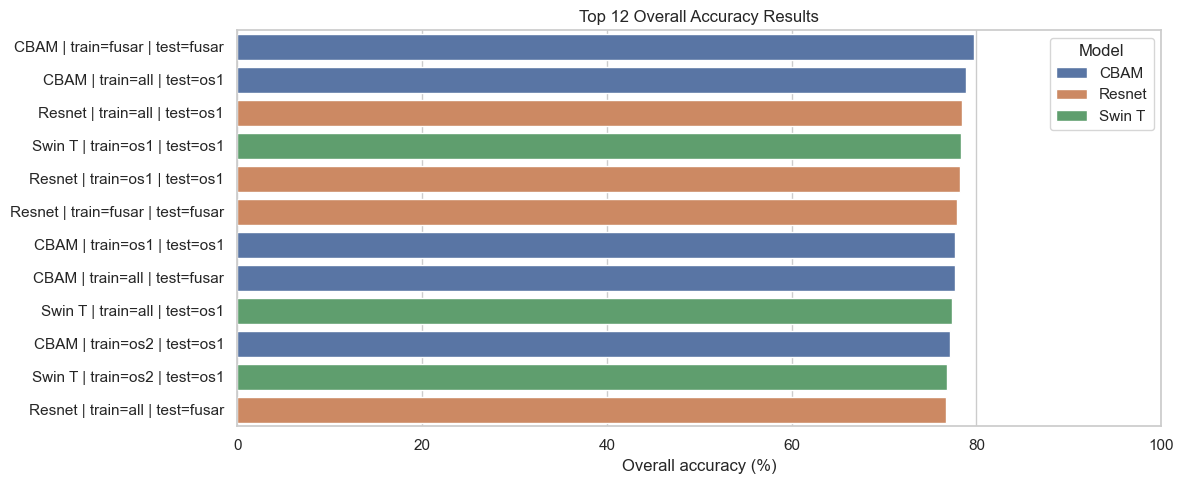

,model,train_split,test_split,overall_acc
10,CBAM,fusar,fusar,79.7258
12,CBAM,all,os1,78.8307
28,Resnet,all,os1,78.4536
32,Swin T,os1,os1,78.3121
16,Resnet,os1,os1,78.1707
26,Resnet,fusar,fusar,77.8648
0,CBAM,os1,os1,77.6992
14,CBAM,all,fusar,77.6690
44,Swin T,all,os1,77.3692
4,CBAM,os2,os1,77.1806


In [16]:
top_overall = df_overall.sort_values("overall_acc", ascending=False).head(12)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=top_overall,
    x="overall_acc",
    y=top_overall.apply(
        lambda r: f"{r['model']} | train={r['train_split']} | test={r['test_split']}", axis=1
    ),
    hue="model",
    dodge=False,
)
plt.title("Top 12 Overall Accuracy Results")
plt.xlabel("Overall accuracy (%)")
plt.ylabel("")
plt.xlim(0, 100)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

top_overall

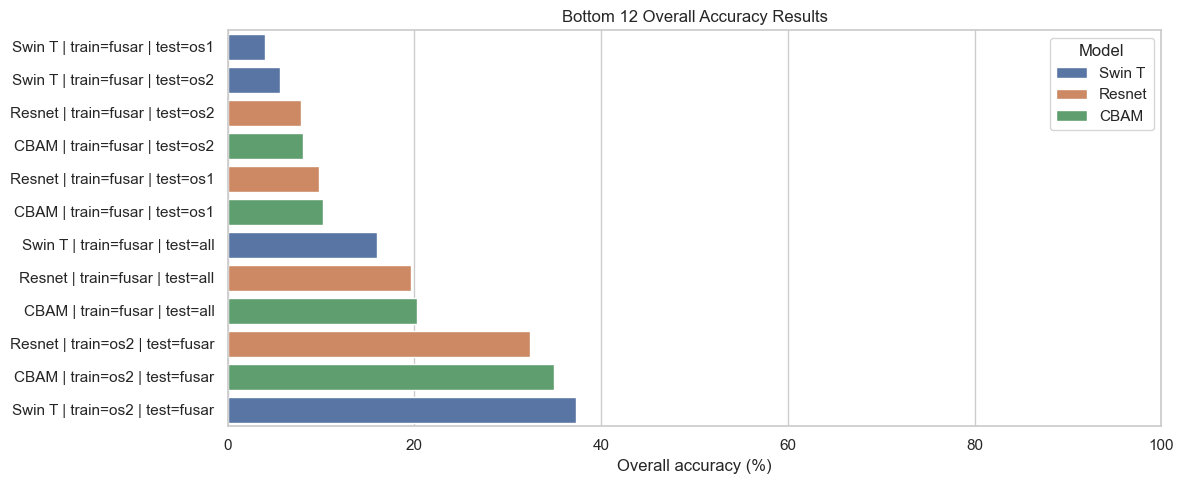

,model,train_split,test_split,overall_acc
40,Swin T,fusar,os1,3.9604
41,Swin T,fusar,os2,5.5897
25,Resnet,fusar,os2,7.8317
9,CBAM,fusar,os2,8.1081
24,Resnet,fusar,os1,9.8067
8,CBAM,fusar,os1,10.1839
43,Swin T,fusar,all,15.9581
27,Resnet,fusar,all,19.6624
11,CBAM,fusar,all,20.2251
22,Resnet,os2,fusar,32.4192


In [17]:
bottom_overall = df_overall.sort_values("overall_acc", ascending=True).head(12)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=bottom_overall,
    x="overall_acc",
    y=bottom_overall.apply(
        lambda r: f"{r['model']} | train={r['train_split']} | test={r['test_split']}", axis=1
    ),
    hue="model",
    dodge=False,
)
plt.title("Bottom 12 Overall Accuracy Results")
plt.xlabel("Overall accuracy (%)")
plt.ylabel("")
plt.xlim(0, 100)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

bottom_overall

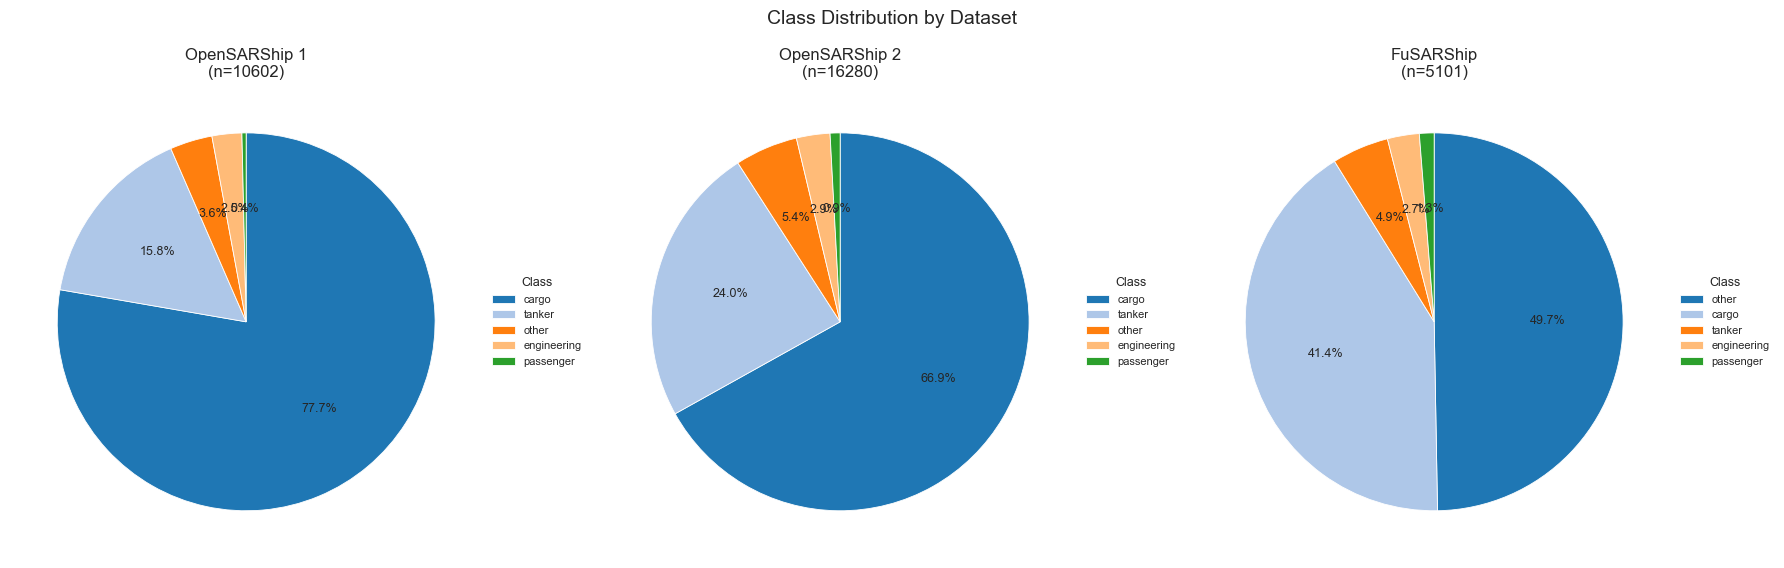

,os1_count,os2_count,fusar_count
label,,,
cargo,8240,10893,2114
tanker,1670,3905,248
other,384,876,2536
engineering,270,467,139
passenger,38,139,64


In [18]:
# Load dataset label files (same pattern used in src notebooks)
DATA_DIR = Path("data/classification/")

opensar1 = pd.read_csv(DATA_DIR / "opensar1_labels.csv")
opensar2 = pd.read_csv(DATA_DIR / "opensar2_labels.csv")
fusar = pd.read_csv(DATA_DIR / "fusar_labels.csv")

# Match baseline eval setup by removing unknown labels
for df in [opensar1, opensar2, fusar]:
    df.drop(df[df["label"] == "unknown"].index, inplace=True)

datasets = {
    "OpenSARShip 1": opensar1,
    "OpenSARShip 2": opensar2,
    "FuSARShip": fusar,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = sns.color_palette("tab20", n_colors=20)

for ax, (name, df) in zip(axes, datasets.items()):
    counts = df["label"].value_counts().sort_values(ascending=False)
    wedges, _, _ = ax.pie(
        counts.values,
        labels=None,
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        colors=colors[: len(counts)],
        textprops={"fontsize": 9},
        wedgeprops={"edgecolor": "white", "linewidth": 0.6},
    )
    ax.legend(
        wedges,
        counts.index,
        title="Class",
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=8,
        title_fontsize=9,
        frameon=False,
    )
    ax.set_title(f"{name}\n(n={len(df)})")

plt.suptitle("Class Distribution by Dataset", fontsize=14)
plt.tight_layout()
plt.show()

# Optional numeric table for exact class counts
dist_table = pd.concat(
    [
        opensar1["label"].value_counts().rename("os1_count"),
        opensar2["label"].value_counts().rename("os2_count"),
        fusar["label"].value_counts().rename("fusar_count"),
    ],
    axis=1,
).fillna(0).astype(int)

dist_table

In [19]:
# Load BAM hierarchical / tiered result files
result_files = {
    "Hierarchical BAM": Path("results/hierarchical_bam_test_results.json"),
    "Tier 1 BAM": Path("results/tier1_bam_test_results.json"),
    "Tier 2 BAM": Path("results/tier2_bam_test_results.json"),
}


def load_bam_result_table(result_path, result_name):
    with result_path.open("r") as f:
        raw = json.load(f)["bam"]

    rows = []
    for train_split, test_dict in raw.items():
        for test_split, metrics in test_dict.items():
            rows.append(
                {
                    "result_set": result_name,
                    "train_split": train_split,
                    "test_split": test_split,
                    "accuracy": metrics["accuracy"],
                    "n_samples": len(metrics["labels"]),
                    "n_classes": len(set(metrics["labels"])),
                }
            )

    return pd.DataFrame(rows)


bam_result_frames = [
    load_bam_result_table(path, name) for name, path in result_files.items()
]
df_bam_results = pd.concat(bam_result_frames, ignore_index=True)

print(f"Loaded {len(df_bam_results)} BAM evaluation rows")
df_bam_results.head()

Loaded 48 BAM evaluation rows


,result_set,train_split,test_split,accuracy,n_samples,n_classes
0,Hierarchical BAM,os1,os1,78.547855,2121,5
1,Hierarchical BAM,os1,os2,64.066339,3256,5
2,Hierarchical BAM,os1,fusar,41.429971,1021,5
3,Hierarchical BAM,os1,joint,65.254767,6398,5
4,Hierarchical BAM,os2,os1,73.173032,2121,5


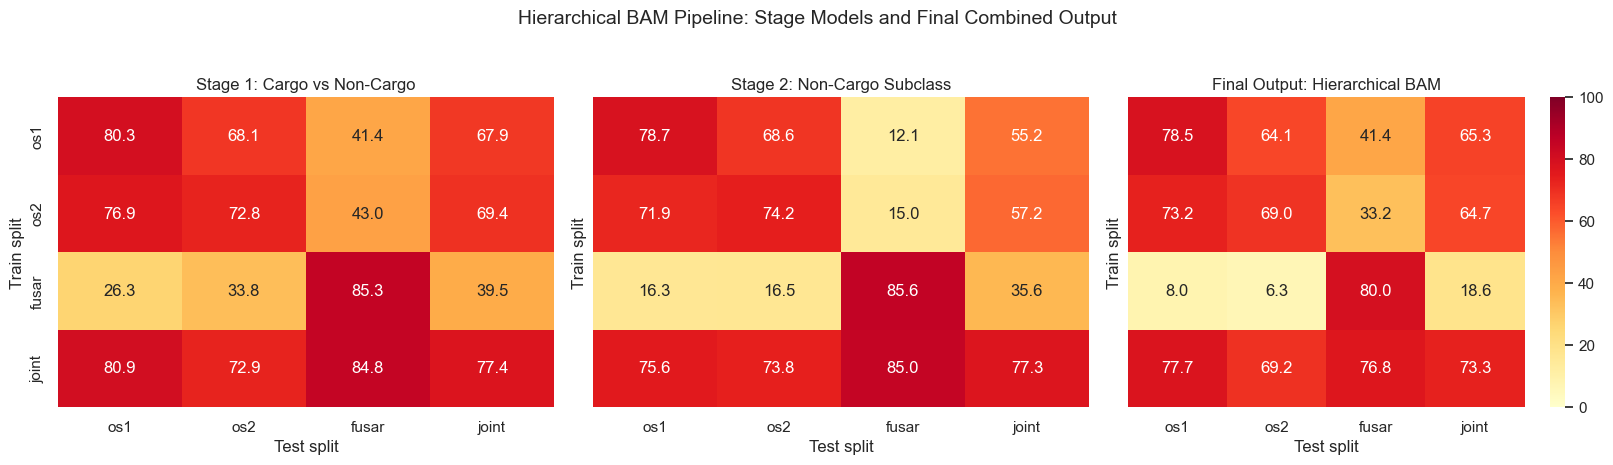

Tier 1 and Tier 2 are intermediate tasks; Hierarchical BAM is the final 5-class system output.


In [26]:
split_order = ["os1", "os2", "fusar", "joint"]
stage_order = ["Tier 1 BAM", "Tier 2 BAM", "Hierarchical BAM"]
stage_title_map = {
    "Tier 1 BAM": "Stage 1: Cargo vs Non-Cargo",
    "Tier 2 BAM": "Stage 2: Non-Cargo Subclass",
    "Hierarchical BAM": "Final Output: Hierarchical BAM",
}

fig, axes = plt.subplots(1, len(stage_order), figsize=(5.5 * len(stage_order), 4.5), sharey=True)

for ax, result_name in zip(axes, stage_order):
    subset = df_bam_results[df_bam_results["result_set"] == result_name].copy()
    subset["train_split"] = pd.Categorical(subset["train_split"], categories=split_order, ordered=True)
    subset["test_split"] = pd.Categorical(subset["test_split"], categories=split_order, ordered=True)

    pivot = subset.pivot(index="train_split", columns="test_split", values="accuracy")
    pivot = pivot.reindex(index=split_order, columns=split_order)

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        vmin=0,
        vmax=100,
        cbar=ax is axes[-1],
        ax=ax,
    )
    ax.set_title(stage_title_map[result_name])
    ax.set_xlabel("Test split")
    ax.set_ylabel("Train split")

fig.suptitle(
    "Hierarchical BAM Pipeline: Stage Models and Final Combined Output",
    fontsize=14,
    y=1.03,
)
plt.tight_layout()
plt.show()

print("Tier 1 and Tier 2 are intermediate tasks; Hierarchical BAM is the final 5-class system output.")

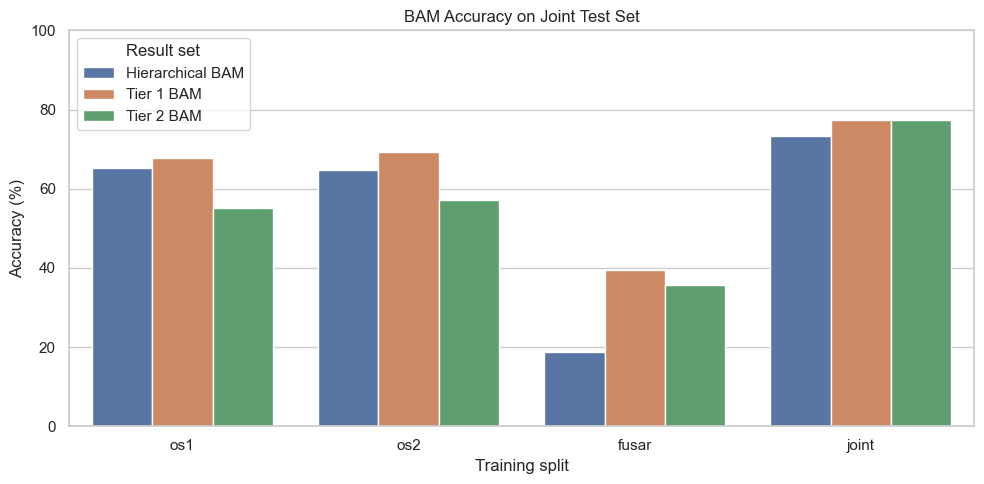

,result_set,train_split,test_split,accuracy,n_samples,n_classes
31,Tier 1 BAM,joint,joint,77.430447,6398,2
47,Tier 2 BAM,joint,joint,77.314815,1728,4
15,Hierarchical BAM,joint,joint,73.257268,6398,5
23,Tier 1 BAM,os2,joint,69.396686,6398,2
19,Tier 1 BAM,os1,joint,67.880588,6398,2
3,Hierarchical BAM,os1,joint,65.254767,6398,5
7,Hierarchical BAM,os2,joint,64.692091,6398,5
39,Tier 2 BAM,os2,joint,57.233796,1728,4
35,Tier 2 BAM,os1,joint,55.150463,1728,4
27,Tier 1 BAM,fusar,joint,39.512348,6398,2


In [21]:
pipeline_compare = df_bam_results.copy()
pipeline_compare["split_pair"] = pipeline_compare.apply(
    lambda r: f"train={r['train_split']}\n test={r['test_split']}",
    axis=1,
)
pipeline_compare["pair_order"] = pipeline_compare["train_split"].map(
    {name: i for i, name in enumerate(split_order)}
) * len(split_order) + pipeline_compare["test_split"].map(
    {name: i for i, name in enumerate(split_order)}
)
pipeline_compare = pipeline_compare.sort_values(["pair_order", "result_set"])

plt.figure(figsize=(16, 6))
sns.barplot(
    data=pipeline_compare,
    x="split_pair",
    y="accuracy",
    hue="result_set",
    hue_order=stage_order,
)
plt.title("Hierarchical BAM Pipeline Accuracy by Train/Test Split")
plt.xlabel("Train/Test split pair")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Pipeline stage / output")
plt.tight_layout()
plt.show()

pipeline_compare[["result_set", "train_split", "test_split", "accuracy", "n_samples", "n_classes"]]

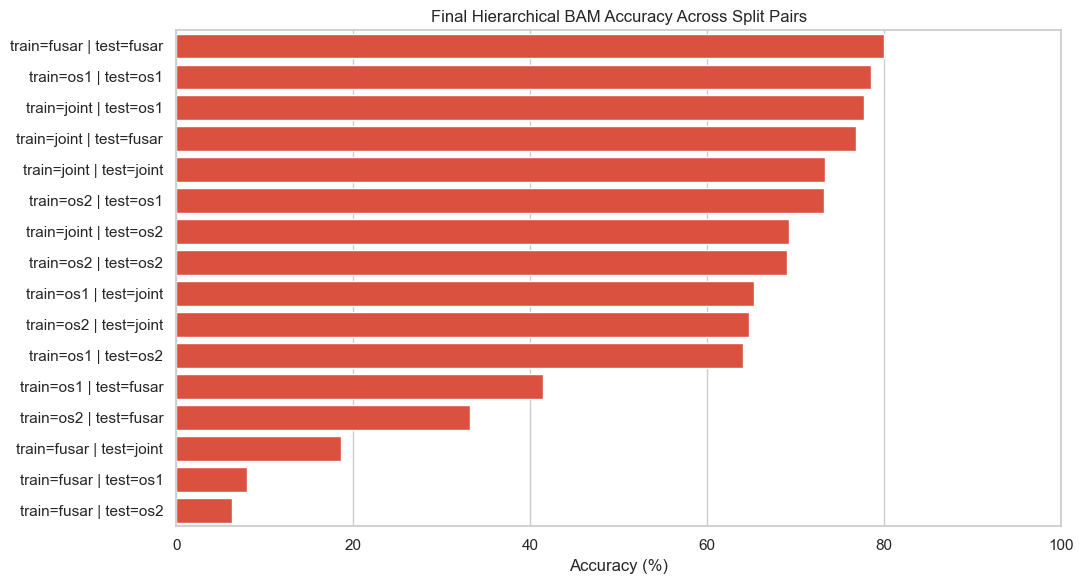

,train_split,test_split,accuracy,n_samples,n_classes
10,fusar,fusar,80.019589,1021,5
0,os1,os1,78.547855,2121,5
12,joint,os1,77.746346,2121,5
14,joint,fusar,76.787463,1021,5
15,joint,joint,73.257268,6398,5
4,os2,os1,73.173032,2121,5
13,joint,os2,69.226044,3256,5
5,os2,os2,69.041769,3256,5
3,os1,joint,65.254767,6398,5
7,os2,joint,64.692091,6398,5


In [25]:
hierarchical_only = df_bam_results[
    df_bam_results["result_set"] == "Hierarchical BAM"
].copy()
hierarchical_only = hierarchical_only.sort_values("accuracy", ascending=False)

hierarchical_only["label"] = hierarchical_only.apply(
    lambda r: f"train={r['train_split']} | test={r['test_split']}",
    axis=1,
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=hierarchical_only,
    x="accuracy",
    y="label",
    color=sns.color_palette("YlOrRd", 5)[3],
)
plt.title("Final Hierarchical BAM Accuracy Across Split Pairs")
plt.xlabel("Accuracy (%)")
plt.ylabel("")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

hierarchical_only[["train_split", "test_split", "accuracy", "n_samples", "n_classes"]]

In [30]:
baseline['bam']

{'os1': {'os1': {'overall': 77.6992,
   'per_class': {'cargo': {'acc': 89.8665, 'correct': 1481, 'total': 1648},
    'engineering': {'acc': 29.6296, 'correct': 16, 'total': 54},
    'other': {'acc': 20.7792, 'correct': 16, 'total': 77},
    'passenger': {'acc': 25.0, 'correct': 2, 'total': 8},
    'tanker': {'acc': 39.8204, 'correct': 133, 'total': 334}}},
  'os2': {'overall': 63.1143,
   'per_class': {'cargo': {'acc': 81.0922, 'correct': 1767, 'total': 2179},
    'engineering': {'acc': 9.6774, 'correct': 9, 'total': 93},
    'other': {'acc': 18.2857, 'correct': 32, 'total': 175},
    'passenger': {'acc': 3.5714, 'correct': 1, 'total': 28},
    'tanker': {'acc': 31.4981, 'correct': 246, 'total': 781}}},
  'fusar': {'overall': 38.2958,
   'per_class': {'cargo': {'acc': 85.5792, 'correct': 362, 'total': 423},
    'engineering': {'acc': 0.0, 'correct': 0, 'total': 28},
    'other': {'acc': 5.7199, 'correct': 29, 'total': 507},
    'passenger': {'acc': 0.0, 'correct': 0, 'total': 13},
    

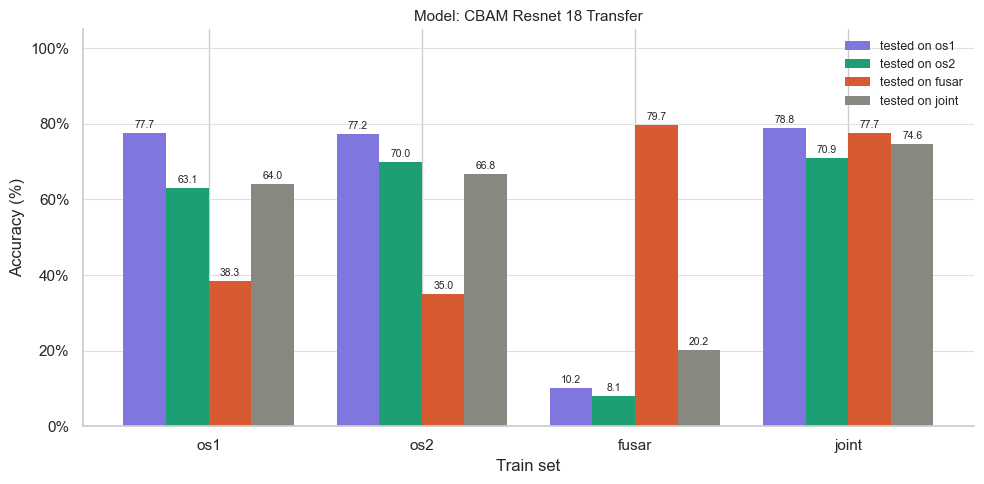

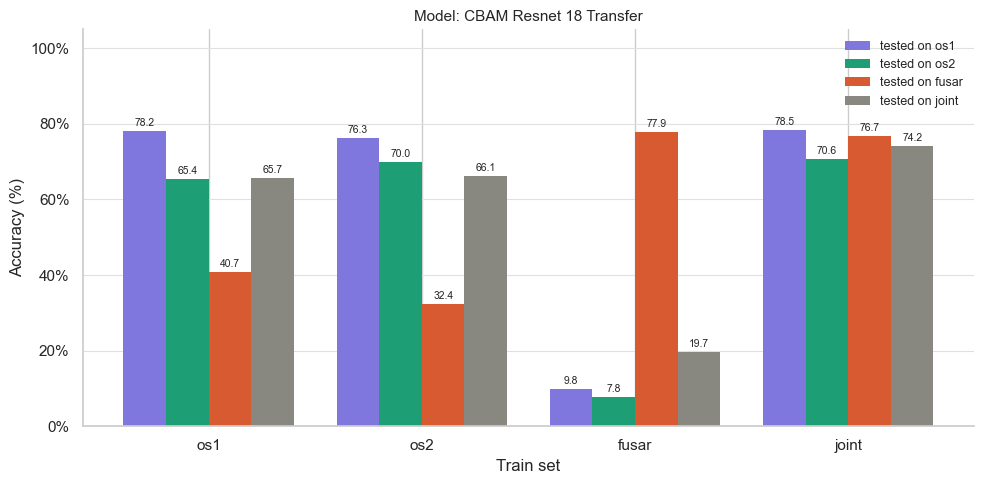

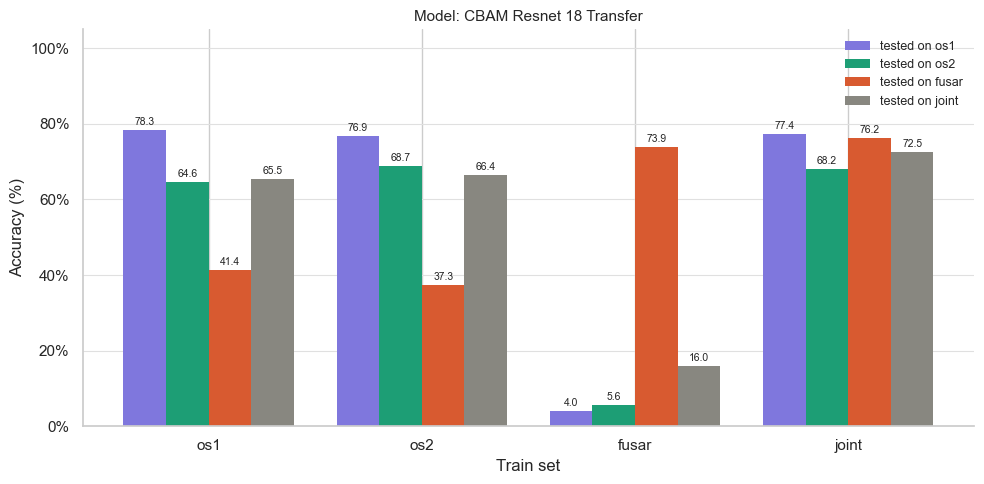

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import json

with open('results/baseline_test_results.json') as f:
    data = json.load(f)

model_keys  = ['bam', 'res', 'vis']
domain_keys = ['os1', 'os2', 'fusar', 'all']
model_colors = ['#7F77DD', '#1D9E75', '#D85A30', '#888780']

for model_key in model_keys:
    results = {
        train: {
            test: data[model_key][train][test]['overall']
            for test in domain_keys
        }
        for train in domain_keys
    }

    x     = np.arange(len(domain_keys))  # train domains on x-axis
    n     = len(domain_keys)             # one bar per test domain
    width = 0.8 / n

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, test_key in enumerate(domain_keys):
        accs    = [results[train][test_key] for train in domain_keys]
        offsets = x + i * width - (n - 1) * width / 2
        label   = 'joint' if test_key == 'all' else test_key
        bars    = ax.bar(offsets, accs, width, label=f"tested on {label}",
                         color=model_colors[i], linewidth=0)
        for bar, acc in zip(bars, accs):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                    f"{acc:.1f}", ha='center', va='bottom', fontsize=7.5)

    ax.set_title(f"Model: CBAM Resnet 18 Transfer", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(['os1', 'os2', 'fusar', 'joint'])
    ax.set_xlabel("Train set")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=9)

    plt.tight_layout()
    plt.show()

In [37]:
hierarchical_only

,result_set,train_split,test_split,accuracy,n_samples,n_classes,label
10,Hierarchical BAM,fusar,fusar,80.019589,1021,5,train=fusar | test=fusar
0,Hierarchical BAM,os1,os1,78.547855,2121,5,train=os1 | test=os1
12,Hierarchical BAM,joint,os1,77.746346,2121,5,train=joint | test=os1
14,Hierarchical BAM,joint,fusar,76.787463,1021,5,train=joint | test=fusar
15,Hierarchical BAM,joint,joint,73.257268,6398,5,train=joint | test=joint
4,Hierarchical BAM,os2,os1,73.173032,2121,5,train=os2 | test=os1
13,Hierarchical BAM,joint,os2,69.226044,3256,5,train=joint | test=os2
5,Hierarchical BAM,os2,os2,69.041769,3256,5,train=os2 | test=os2
3,Hierarchical BAM,os1,joint,65.254767,6398,5,train=os1 | test=joint
7,Hierarchical BAM,os2,joint,64.692091,6398,5,train=os2 | test=joint


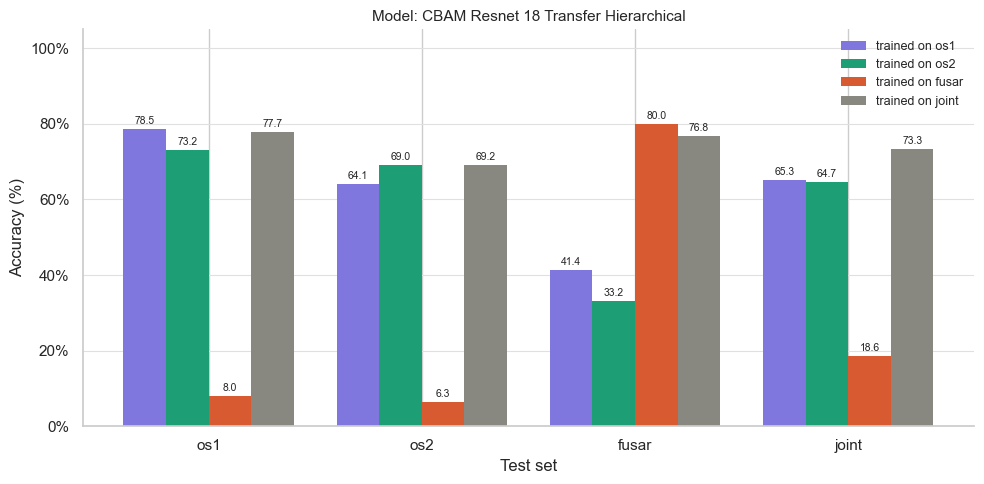

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import json

with open('results/hierarchical_bam_test_results.json') as f:
    data = json.load(f)


model_keys  = ['bam']
domain_keys = ['os1', 'os2', 'fusar', 'joint']
model_colors = ['#7F77DD', '#1D9E75', '#D85A30', '#888780']

for model_key in model_keys:
    # results[train_domain][test_domain] -> overall accuracy
    results = {
        train: {
            test: data[model_key][train][test]['accuracy']
            for test in domain_keys
        }
        for train in domain_keys
    }

    x     = np.arange(len(domain_keys))  # test domains on x-axis
    n     = len(domain_keys)             # one bar per train domain
    width = 0.8 / n

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, train_key in enumerate(domain_keys):
        accs    = [results[train_key][t] for t in domain_keys]
        offsets = x + i * width - (n - 1) * width / 2
        bars    = ax.bar(offsets, accs, width, label=f"trained on {train_key}",
                         color=model_colors[i], linewidth=0)
        for bar, acc in zip(bars, accs):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                    f"{acc:.1f}", ha='center', va='bottom', fontsize=7.5)

    ax.set_title(f"Model: CBAM Resnet 18 Transfer Hierarchical", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(domain_keys)
    ax.set_xlabel("Test set")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=9)

    plt.tight_layout()
    plt.show()

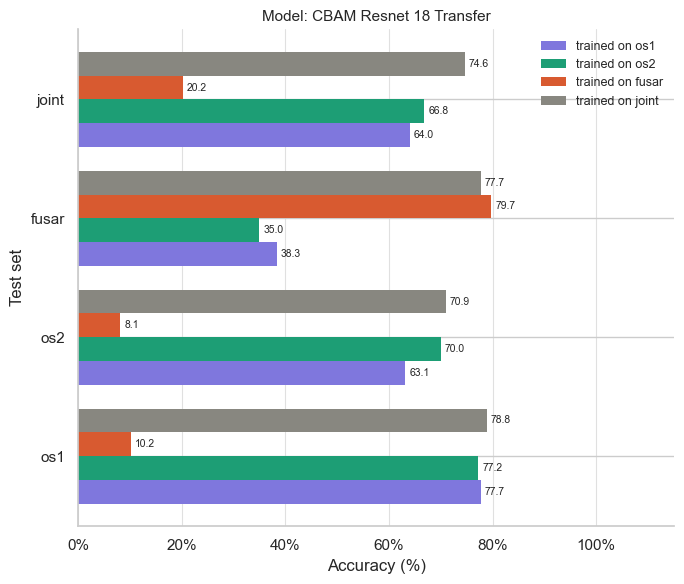

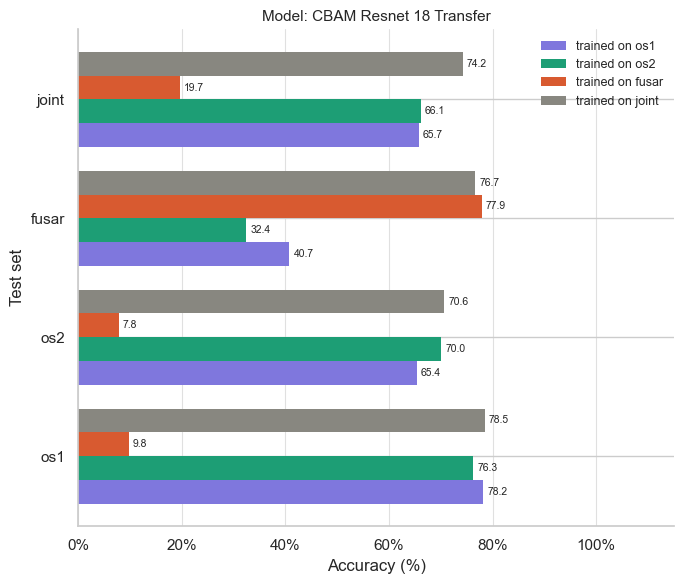

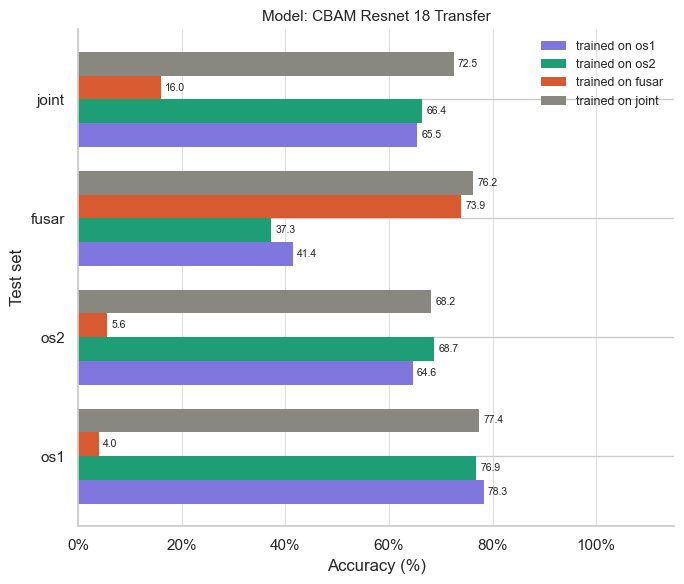

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import json

with open('results/baseline_test_results.json') as f:
    data = json.load(f)

model_keys  = ['bam', 'res', 'vis']
domain_keys = ['os1', 'os2', 'fusar', 'all']
model_colors = ['#7F77DD', '#1D9E75', '#D85A30', '#888780']

for model_key in model_keys:
    results = {
        train: {
            test: data[model_key][train][test]['overall']
            for test in domain_keys
        }
        for train in domain_keys
    }

    y     = np.arange(len(domain_keys))  # test domains on y-axis
    n     = len(domain_keys)
    height = 0.8 / n

    fig, ax = plt.subplots(figsize=(7, 6))

    for i, train_key in enumerate(domain_keys):
        accs    = [results[train_key][t] for t in domain_keys]
        offsets = y + i * height - (n - 1) * height / 2
        label   = 'joint' if train_key == 'all' else train_key
        bars    = ax.barh(offsets, accs, height, label=f"trained on {label}",
                          color=model_colors[i], linewidth=0)
        for bar, acc in zip(bars, accs):
            ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
                    f"{acc:.1f}", ha='left', va='center', fontsize=7.5)

    ax.set_title(f"Model: CBAM Resnet 18 Transfer", fontsize=11)
    ax.set_yticks(y)
    ax.set_yticklabels(['os1', 'os2', 'fusar', 'joint'])
    ax.set_ylabel("Test set")
    ax.set_xlabel("Accuracy (%)")
    ax.set_xlim(0, 115)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', color='#e0e0e0', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=9)

    plt.tight_layout()
    plt.show()

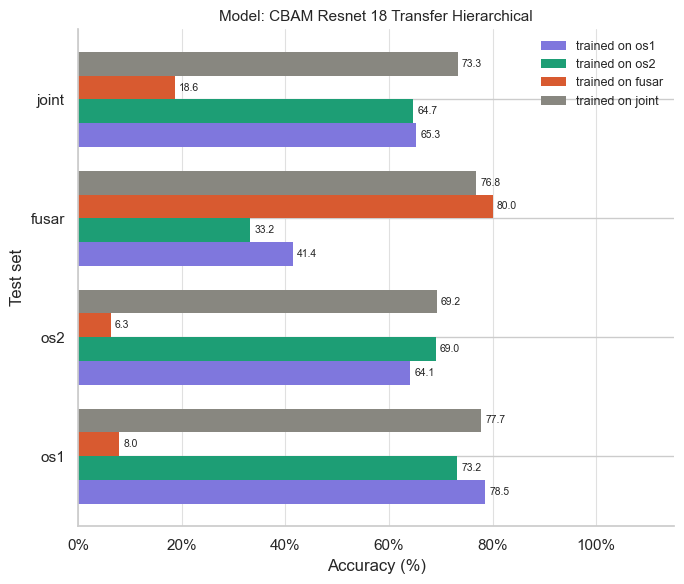

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import json

with open('results/hierarchical_bam_test_results.json') as f:
    data = json.load(f)

model_keys  = ['bam']
domain_keys = ['os1', 'os2', 'fusar', 'joint']
model_colors = ['#7F77DD', '#1D9E75', '#D85A30', '#888780']

for model_key in model_keys:
    results = {
        train: {
            test: data[model_key][train][test]['accuracy']
            for test in domain_keys
        }
        for train in domain_keys
    }

    y      = np.arange(len(domain_keys))
    n      = len(domain_keys)
    height = 0.8 / n

    fig, ax = plt.subplots(figsize=(7, 6))

    for i, train_key in enumerate(domain_keys):
        accs    = [results[train_key][t] for t in domain_keys]
        offsets = y + i * height - (n - 1) * height / 2
        bars    = ax.barh(offsets, accs, height, label=f"trained on {train_key}",
                          color=model_colors[i], linewidth=0)
        for bar, acc in zip(bars, accs):
            ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
                    f"{acc:.1f}", ha='left', va='center', fontsize=7.5)

    ax.set_title(f"Model: CBAM Resnet 18 Transfer Hierarchical", fontsize=11)
    ax.set_yticks(y)
    ax.set_yticklabels(domain_keys)
    ax.set_ylabel("Test set")
    ax.set_xlabel("Accuracy (%)")
    ax.set_xlim(0, 115)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', color='#e0e0e0', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=9)

    plt.tight_layout()
    plt.show()

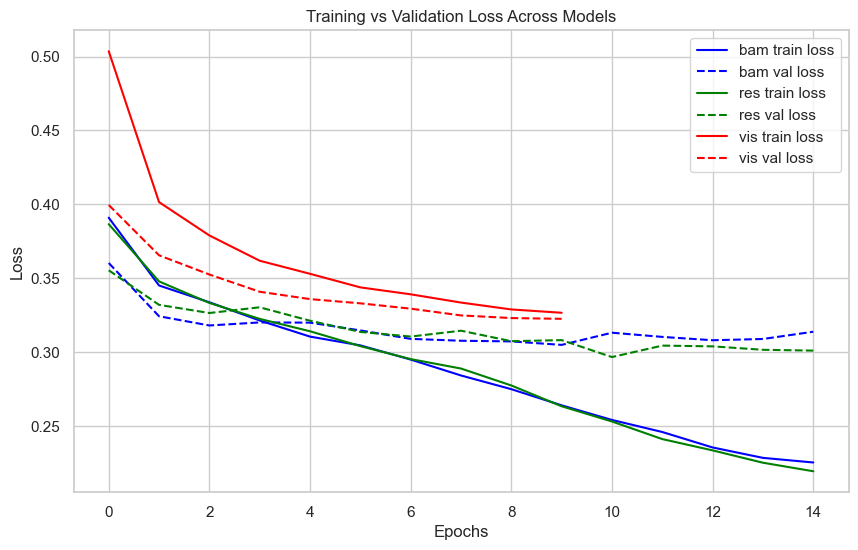

In [64]:
import json
import matplotlib.pyplot as plt

with open('results/baseline_history/baseline_history.json') as f:
    data = json.load(f)

models = ['bam__all', 'res__all', 'vis__all']

# assign consistent colors per model
colors = {
    'bam__all': 'blue',
    'res__all': 'green',
    'vis__all': 'red'
}

plt.figure(figsize=(10, 6))

for model in models:
    m = data[model]
    model_name = model.split('__')[0]
    
    # train_loss (solid)
    plt.plot(
        m['train_loss'],
        color=colors[model],
        linestyle='-',
        label=f"{model_name} train loss"
    )
    
    # val_loss (dashed)
    plt.plot(
        m['val_loss'],
        color=colors[model],
        linestyle='--',
        label=f"{model_name} val loss"
    )

plt.title("Training vs Validation Loss Across Models")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

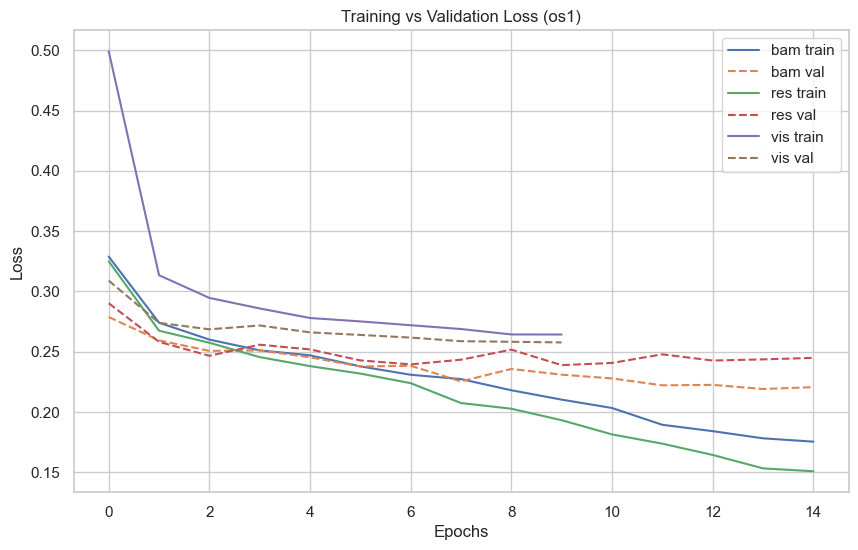

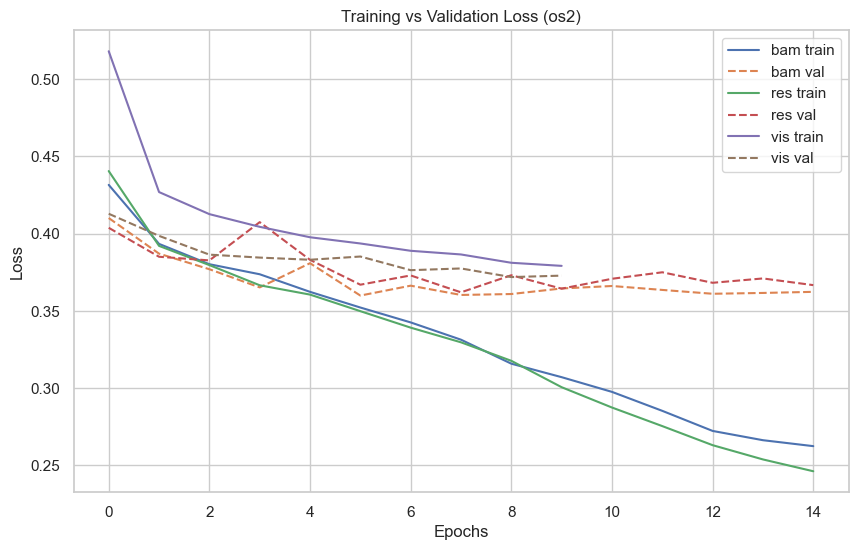

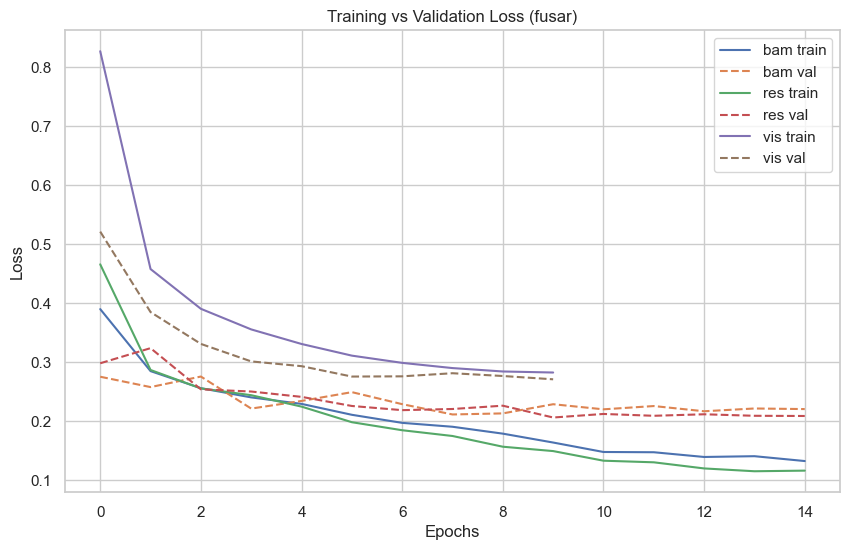

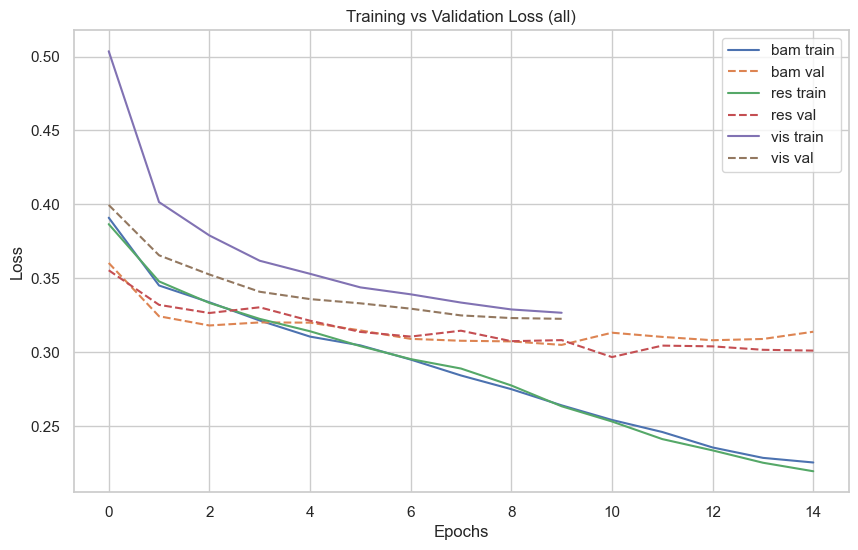

In [63]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

with open('results/baseline_history/baseline_history.json') as f:
    data = json.load(f)

# Step 1: group models by dataset
dataset_groups = defaultdict(list)

for model in data.keys():
    model_name, dataset = model.split('__')
    dataset_groups[dataset].append(model)

# Step 2: plot per dataset
for dataset, model_list in dataset_groups.items():
    plt.figure(figsize=(10, 6))
    
    for model in model_list:
        m = data[model]
        model_name = model.split('__')[0]
        
        # train_loss (solid)
        plt.plot(
            m['train_loss'],
            linestyle='-',
            label=f"{model_name} train"
        )
        
        # val_loss (dashed)
        plt.plot(
            m['val_loss'],
            linestyle='--',
            label=f"{model_name} val"
        )
    
    plt.title(f"Training vs Validation Loss ({dataset})")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    
    plt.show()